<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%202-3/3-EDA-BluAppReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 3 - Exploratory Data Analysis Blu App Review**
This notebook continues the review scraping process previously explained in [2-Preprocessing-BluAppReview.ipynb](https://colab.research.google.com/drive/1rvD4V6iGDOV18xzLEEkwqFZQ4ZBqPwbH?usp=sharing)

#**Setup and Import Libraries**

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install nltk

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import ast

#**Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

    try:
        df_bluRev = pd.read_csv(io.BytesIO(uploaded[fn]))
        print("Successfully loaded CSV into df_bluRev")

    except pd.errors.ParserError:
        print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
        df_bluRev = pd.DataFrame()

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        df_bluRev = pd.DataFrame()

Saving df_bluRev_preprocessed (1).csv to df_bluRev_preprocessed (1).csv
User uploaded file "df_bluRev_preprocessed (1).csv" with length 12315402 bytes
Successfully loaded CSV into df_bluRev


#**(1) Data Overview**

In [ ]:
# Convert 'at' column to datetime format
df_bluRev['at'] = pd.to_datetime(df_bluRev['at'])

# Display dataset info and first few rows
df_bluRev.info()
df_bluRev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24968 entries, 0 to 24967
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   content          24968 non-null  object        
 1   score            24968 non-null  int64         
 2   at               24968 non-null  datetime64[ns]
 3   thumbsUpCount    24968 non-null  int64         
 4   replyContent     24968 non-null  object        
 5   sentiment_label  24968 non-null  object        
 6   final_content    24968 non-null  object        
 7   tokens_stemmed   24968 non-null  object        
 8   review_year      24968 non-null  period[Y-DEC] 
dtypes: datetime64[ns](1), int64(2), object(5), period[Y-DEC](1)
memory usage: 1.7+ MB


,content,score,at,thumbsUpCount,replyContent,sentiment_label,final_content,tokens_stemmed,review_year
0,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",2,2026-03-30 09:10:30,0,"Hai, Kak Indah. Maaf atas ketidaknyamanannya. ...",negative,minggu buka ganti jaring dn ganti hp sih data ...,"[minggu, buka, ganti, jaring, dn, ganti, hp, s...",2026
1,"bener bener kecewa sama aplikasi ini, gw kira ...",1,2026-03-30 08:05:12,0,"Hai, Kak Esa. Maaf atas ketidaknyamanannya. BC...",negative,kecewa percaya recomended kantor cabang fisik ...,"[kecewa, percaya, recomended, kantor, cabang, ...",2026
2,mantap,5,2026-03-30 08:01:13,0,"Hai, Kak Abdul. Terima kasih atas ulasannya. S...",positive,bagus,[bagus],2026
3,digital bank terbaik gaperlu ribet lagi pembay...,5,2026-03-30 07:38:52,0,"Hai, Kak Kenzin. Terima kasih atas ulasannya. ...",positive,baik gaperlu ribet bayar jenis apa,"[baik, gaperlu, ribet, bayar, jenis, apa]",2026
4,"aku tinggalkan blu, karena aplikasinya super l...",5,2026-03-30 07:00:00,0,"Hai, Kak Rizal. Maaf atas ketidaknyamanannya. ...",positive,tinggal aplikasi super lambat,"[tinggal, aplikasi, super, lambat]",2026


#**(2) Missing Values Analysis**

In [ ]:
missing_values = df_bluRev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
content            0
score              0
at                 0
thumbsUpCount      0
replyContent       0
sentiment_label    0
final_content      0
tokens_stemmed     0
dtype: int64


## **(3) Review Score Distribution**

/tmp/ipykernel_3601/2683483179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_bluRev['score'], palette="viridis")


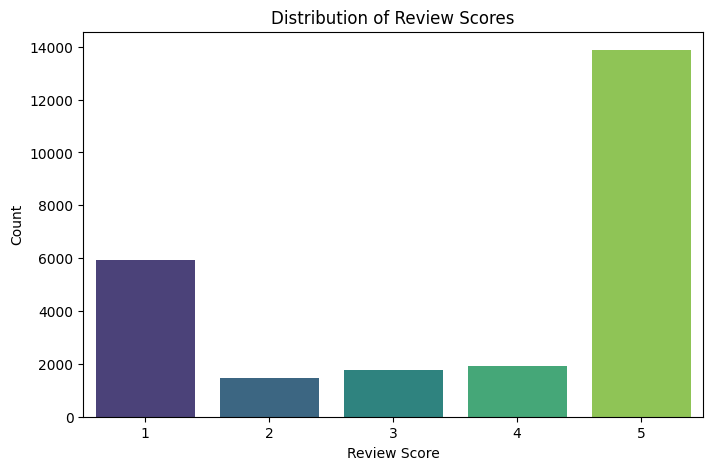

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_bluRev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

## **(4) Review Trends Over Time**

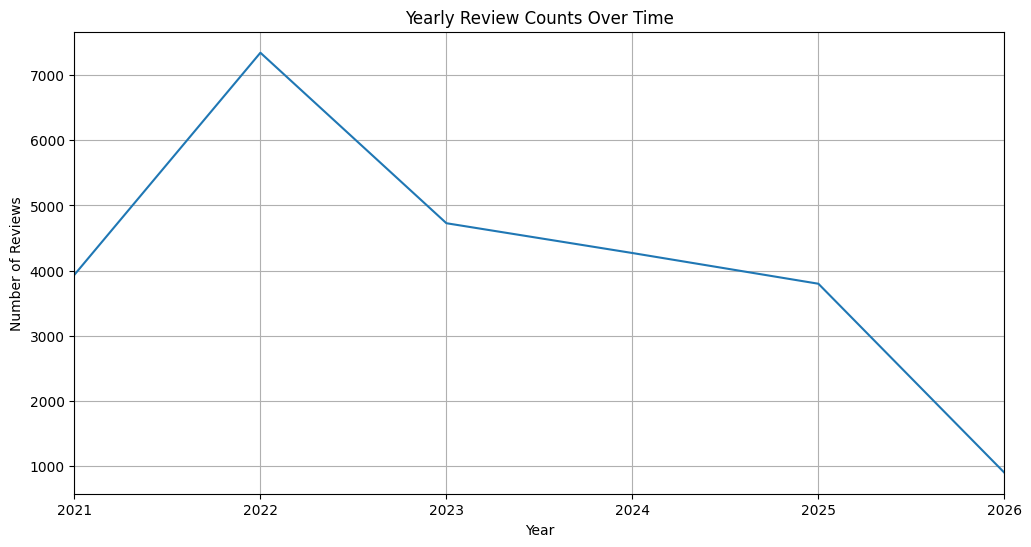

In [ ]:
# Extract review date
df_bluRev['review_year'] = df_bluRev['at'].dt.to_period('Y')
review_trend = df_bluRev.groupby('review_year').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Yearly Review Counts Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

## **(5) Word Frequency Analysis**

In [ ]:
all_tokens = [token for tokens in df_bluRev['tokens_stemmed'] for token in tokens]
word_counts = Counter(all_tokens)
common_words = pd.DataFrame(word_counts.most_common(50), columns=['Word', 'Frequency'])

print("Most Common Words in Reviews:")
print(common_words)


Most Common Words in Reviews:
          Word  Frequency
0        bagus       5952
1       banget       3024
2        masuk       2454
3        mudah       2394
4        pakai       2332
5    transaksi       2126
6         buka       1570
7       lambat       1436
8     transfer       1395
9        bantu       1376
10      tolong       1346
11      daftar       1324
12    rekening       1210
13    aplikasi       1159
14        baik       1154
15       biaya       1107
16       susah       1071
17       kasih       1022
18       tunai       1005
19  verifikasi        970
20       admin        960
21       bayar        958
22       cepat        957
23          ok        949
24       tarik        940
25       fitur        918
26        uang        916
27       ribet        889
28        baru        886
29       gagal        884
30        moga        808
31       kartu        804
32         pas        789
33       buruk        749
34      terima        742
35        coba        741
36      

#**(6) Top Words Based on Sentiment**

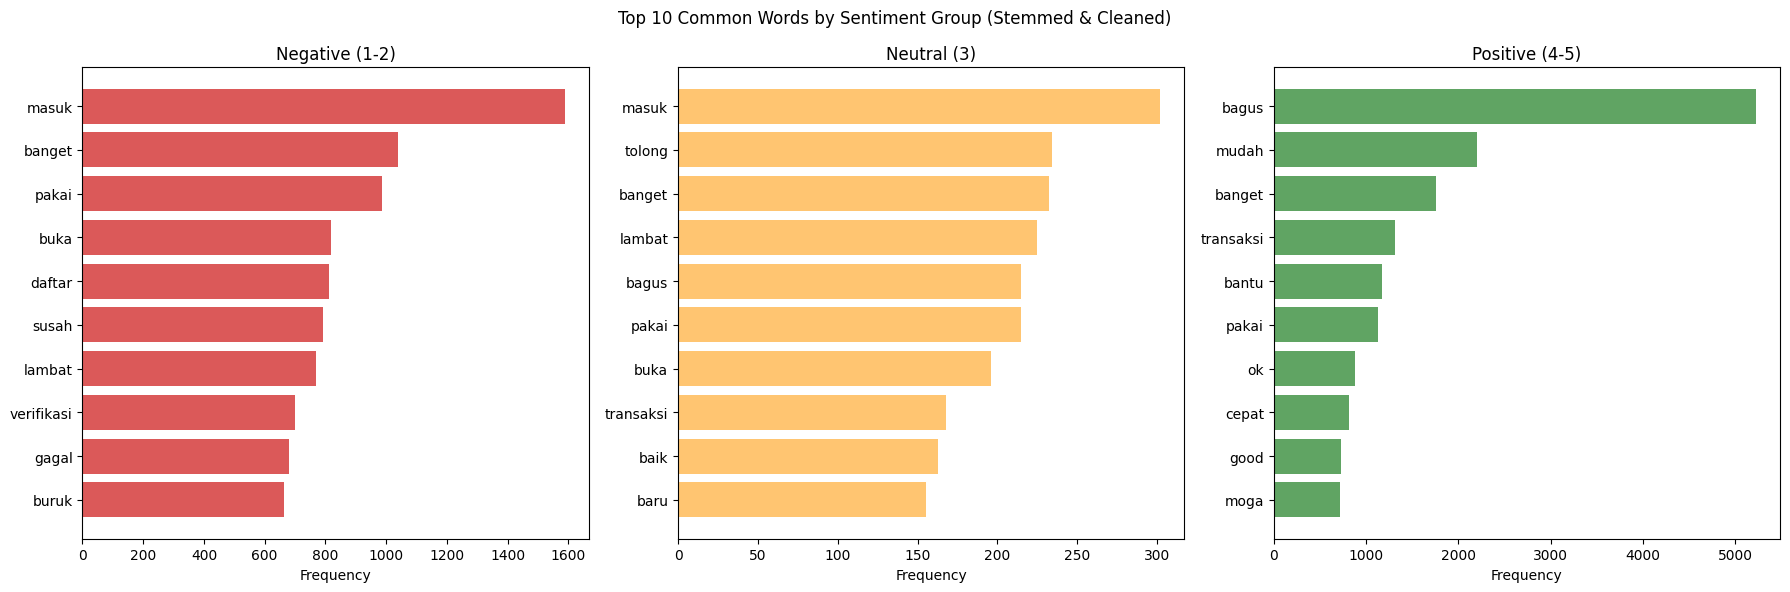

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

groups = {
    'Negative (1-2)': df_bluRev[df_bluRev['score'].isin([1, 2])],
    'Neutral (3)': df_bluRev[df_bluRev['score'] == 3],
    'Positive (4-5)': df_bluRev[df_bluRev['score'].isin([4, 5])]
}
group_colors = ['#d32f2f', '#ffb74d', '#388e3c']

for ax, (label, group_df), color in zip(axes, groups.items(), group_colors):
    all_tokens_group = [token for tokens in group_df['tokens_stemmed'] for token in tokens]
    top_words = Counter(all_tokens_group).most_common(10)
    words, counts = zip(*top_words)

    # Visualization
    ax.barh(range(len(words)), counts, color=color, alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(label)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 10 Common Words by Sentiment Group (Stemmed & Cleaned)')
plt.tight_layout()
plt.show()